# Assignment 5: RNN, LSTM and GRU for Sequence Classification

## Aim

Implement and compare **Recurrent Neural Network (RNN)**, **Long Short-Term Memory (LSTM)**, and **Gated Recurrent Unit (GRU)** models for sequence classification and analyze their performance using appropriate evaluation metrics.

## Problem Statement

Implement and compare RNN, LSTM, and GRU models for sequence classification, and analyze their performance using appropriate evaluation metrics.

## Dataset

For this assignment, the **IMDB Movie Reviews Dataset** is used.

The dataset contains **50,000 movie reviews** labeled as either:

- `0` → Negative sentiment
- `1` → Positive sentiment

Each movie review is a sequence of words. Therefore, this dataset is suitable for demonstrating sequence-based deep learning models such as RNN, LSTM, and GRU.

The dataset will be loaded directly using the TensorFlow/Keras dataset API, so no manual downloading or Google Drive upload is required.

## Objectives

1. Load and preprocess the IMDB text sequence dataset.
2. Convert reviews into numerical sequences suitable for neural networks.
3. Apply padding so that all input sequences have the same length.
4. Build a basic RNN model for sentiment classification.
5. Build an LSTM model for sentiment classification.
6. Build a GRU model for sentiment classification.
7. Train and evaluate all three models.
8. Calculate Accuracy, Precision, Recall, and F1-score.
9. Generate confusion matrices for model evaluation.
10. Compare the models based on performance and training time.
11. Understand why LSTM and GRU can handle long-term dependencies better than a basic RNN.

## Models Used

### 1. RNN
A Recurrent Neural Network processes sequential data while maintaining information from previous time steps. It is simple and useful for understanding the basic idea of sequence modeling.

### 2. LSTM
Long Short-Term Memory is an improved type of RNN that uses gates to control what information should be remembered, forgotten, and passed forward. It helps reduce the vanishing-gradient problem of basic RNNs.

### 3. GRU
Gated Recurrent Unit is another improved RNN architecture. It uses fewer gates than LSTM, making it simpler and often faster while still being capable of learning long-term dependencies.

## Main Deep Learning Concepts

The assignment will demonstrate commonly used concepts such as:

- Tokenization / Integer Encoding
- Sequence Padding
- Embedding Layer
- Recurrent Neural Networks
- LSTM
- GRU
- Binary Classification
- Sigmoid Activation
- Binary Cross-Entropy Loss
- Adam Optimizer
- Train-Test Split
- Epochs and Batch Size
- Model Evaluation

## Evaluation Metrics

The models will be evaluated using:

- **Accuracy** – Overall percentage of correct predictions.
- **Precision** – How many predicted positive samples are actually positive.
- **Recall** – How many actual positive samples are correctly identified.
- **F1-score** – Harmonic mean of Precision and Recall.
- **Confusion Matrix** – Shows correct and incorrect predictions for each class.
- **Training Time** – Used to compare computational efficiency.

## Expected Outcome

The performance of RNN, LSTM, and GRU will be compared to understand their differences in:

- Classification performance
- Ability to learn sequential dependencies
- Training efficiency
- Model complexity

The experiment will help demonstrate why gated architectures such as LSTM and GRU are commonly preferred over basic RNNs for many sequence-learning problems.

In [ ]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display TensorFlow version
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# Load the IMDB Movie Reviews dataset

from tensorflow.keras.datasets import imdb

# Number of most frequent words to keep
vocab_size = 10000

# Load training and testing data
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("First review (encoded):", X_train[0][:20])
print("First review label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First review label: 1


## Sequence Padding

Movie reviews have different lengths. For example:

Review 1 → 50 words  
Review 2 → 120 words  
Review 3 → 300 words

Neural networks generally require inputs in a consistent shape within a batch.

Therefore, we use **sequence padding** to make every review the same length.

For this assignment, we will use a maximum sequence length of **200 words**.

- If a review has fewer than 200 words → add `0`s.
- If a review has more than 200 words → truncate the extra words.

Example:

Original:
[12, 45, 78, 91]

After padding to length 6:
[12, 45, 78, 91, 0, 0]

This gives every review the same input shape:

`(number_of_reviews, 200)`

Padding is important because it allows us to efficiently train our RNN, LSTM, and GRU models using batches of data.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Maximum number of words/tokens in each review
max_length = 200

# Pad and truncate training and testing sequences
X_train_padded = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Original first review length:", len(X_train[0]))
print("Padded first review length:", len(X_train_padded[0]))

print("\nTraining data shape:", X_train_padded.shape)
print("Testing data shape:", X_test_padded.shape)

print("\nFirst padded review:")
print(X_train_padded[0])

Original first review length: 218
Padded first review length: 200

Training data shape: (25000, 200)
Testing data shape: (25000, 200)

First padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   

## Embedding Layer

The reviews are currently represented using integer IDs, where each number represents a word.

However, these integer values do not contain meaningful information about the relationship between words.

For example:

[15, 27, 103, 45]

The model should not interpret `103` as being more important than `15` simply because its number is larger.

An **Embedding Layer** converts each word ID into a dense numerical vector.

For example:

Word ID → Embedding Vector

15 → [0.12, -0.45, 0.78, ...]
27 → [0.31,  0.22, -0.16, ...]
103 → [-0.52, 0.67, 0.11, ...]

These vectors are learned automatically during training.

In this assignment, the Embedding layer will be placed before the RNN, LSTM, and GRU layers so that all three models receive meaningful vector representations of the input words.

In [ ]:
# Common parameters for all three models
vocab_size = 10000       # Number of words in the vocabulary
embedding_dim = 64       # Size of each word's embedding vector
rnn_units = 64           # Number of neurons/units in the recurrent layer
batch_size = 64           # Number of samples processed at once
epochs = 5                # Number of complete passes through training data

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Recurrent units:", rnn_units)
print("Batch size:", batch_size)
print("Epochs:", epochs)

Vocabulary size: 10000
Embedding dimension: 64
Recurrent units: 64
Batch size: 64
Epochs: 5


In [ ]:
# Build the RNN model

rnn_model = keras.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    layers.SimpleRNN(rnn_units),

    layers.Dense(1, activation='sigmoid')
])

# Compile the model
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the RNN model
rnn_model = keras.Sequential([
    layers.Input(shape=(max_length,)),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    layers.SimpleRNN(rnn_units),

    layers.Dense(1, activation='sigmoid')
])

# Compile the model
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Display model architecture
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the RNN model and measure training time
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(f"\nRNN Training Time: {rnn_training_time:.2f} seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5037 - loss: 0.6961 - val_accuracy: 0.5052 - val_loss: 0.6936
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5326 - loss: 0.6894 - val_accuracy: 0.5104 - val_loss: 0.6926
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5911 - loss: 0.6593 - val_accuracy: 0.5180 - val_loss: 0.7032
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6605 - loss: 0.5691 - val_accuracy: 0.4970 - val_loss: 0.7184
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6967 - loss: 0.5101 - val_accuracy: 0.5122 - val_loss: 0.8353

RNN Training Time: 37.25 seconds


In [ ]:
# Evaluate the RNN model on the test dataset

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
  X_test_padded,
  y_test,
  batch_size=batch_size,
  verbose=1
)

print(f"\nRNN Test Loss: {rnn_test_loss:.4f}")
print(f"RNN Test Accuracy: {rnn_test_accuracy:.4f}")
print(f"RNN Test Accuracy: {rnn_test_accuracy * 100:.2f}%")

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5095 - loss: 0.8366

RNN Test Loss: 0.8366
RNN Test Accuracy: 0.5095
RNN Test Accuracy: 50.95%


In [ ]:
# Generate predictions using the trained RNN model
rnn_probabilities = rnn_model.predict(
    X_test_padded,
    batch_size=batch_size,
    verbose=1
)

# Convert probabilities into class labels
rnn_predictions = (rnn_probabilities >= 0.5).astype(int).flatten()

# Calculate evaluation metrics
rnn_accuracy = accuracy_score(y_test, rnn_predictions)
rnn_precision = precision_score(y_test, rnn_predictions)
rnn_recall = recall_score(y_test, rnn_predictions)
rnn_f1 = f1_score(y_test, rnn_predictions)

print("RNN Evaluation Metrics")
print("-" * 30)
print(f"Accuracy : {rnn_accuracy:.4f}")
print(f"Precision: {rnn_precision:.4f}")
print(f"Recall   : {rnn_recall:.4f}")
print(f"F1-Score : {rnn_f1:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
RNN Evaluation Metrics
------------------------------
Accuracy : 0.5095
Precision: 0.5092
Recall   : 0.5292
F1-Score : 0.5190


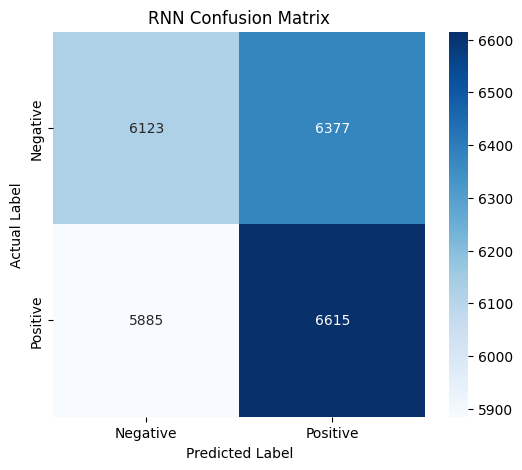

In [ ]:
# Create confusion matrix for RNN
rnn_cm = confusion_matrix(y_test, rnn_predictions)
plt.figure(figsize=(6, 5))

sns.heatmap(
  rnn_cm,
  annot=True,
  fmt='d',
  cmap='Blues',
  xticklabels=['Negative', 'Positive'],
  yticklabels=['Negative', 'Positive']
)

plt.title('RNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

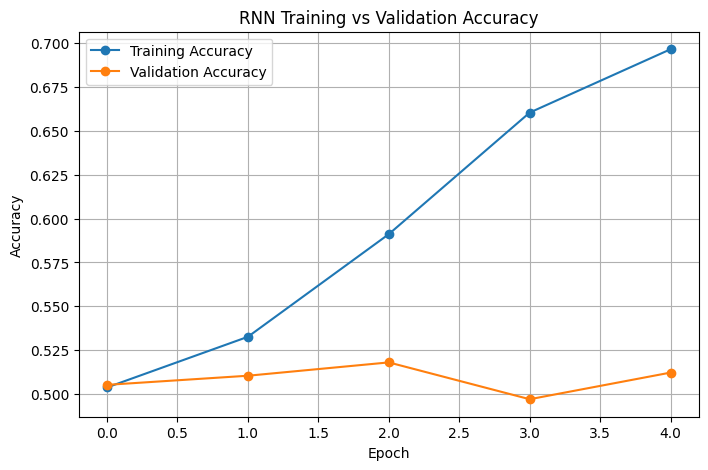

In [ ]:
# Plot RNN training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(
  rnn_history.history['accuracy'],
  marker='o',
  label='Training Accuracy'
)

plt.plot(
  rnn_history.history['val_accuracy'],
  marker='o',
  label='Validation Accuracy'
)

plt.title('RNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Why LSTM?

A basic RNN can have difficulty remembering information from earlier parts of a long sequence because of the **vanishing gradient problem**.

For example, in a long movie review:

"The movie starts slowly ... [many words] ... but the ending is excellent."

A basic RNN may lose some information about the earlier words as it processes the sequence.

### LSTM (Long Short-Term Memory)

LSTM is an improved form of RNN that uses a **memory cell and gates** to control information flow.

The main gates are:

- **Forget Gate** → decides what old information should be removed.
- **Input Gate** → decides what new information should be stored.
- **Output Gate** → decides what information should be passed to the next step.

This allows LSTM to preserve useful information for longer sequences and helps reduce the vanishing-gradient problem.

In this assignment, we will use the same embedding dimension and number of recurrent units as the RNN so that the comparison is reasonably fair.

In [ ]:
# Build the LSTM model

lstm_model = keras.Sequential([
    layers.Input(shape=(max_length,)),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    layers.LSTM(rnn_units),

    layers.Dense(1, activation='sigmoid')
])

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model and measure training time
start_time = time.time()
lstm_history = lstm_model.fit(
  X_train_padded,
  y_train,
  validation_split=0.2,
  epochs=epochs,
  batch_size=batch_size,
  verbose=1
)

lstm_training_time = time.time() - start_time
print(f"\nLSTM Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5538 - loss: 0.6770 - val_accuracy: 0.5504 - val_loss: 0.6738
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5512 - loss: 0.6771 - val_accuracy: 0.5214 - val_loss: 0.6905
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6139 - loss: 0.6496 - val_accuracy: 0.5678 - val_loss: 0.6726
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7440 - loss: 0.5191 - val_accuracy: 0.7850 - val_loss: 0.4728
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5868 - loss: 0.6505 - val_accuracy: 0.5836 - val_loss: 0.6521

LSTM Training Time: 24.76 seconds


In [ ]:
# Evaluate the LSTM model on the test dataset

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
  X_test_padded,
  y_test,
  batch_size=batch_size,
  verbose=1
)

print(f"\nLSTM Test Loss: {lstm_test_loss:.4f}")
print(f"LSTM Test Accuracy: {lstm_test_accuracy:.4f}")
print(f"LSTM Test Accuracy: {lstm_test_accuracy * 100:.2f}%")

391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5681 - loss: 0.6674

LSTM Test Loss: 0.6674
LSTM Test Accuracy: 0.5681
LSTM Test Accuracy: 56.81%


In [ ]:
# Generate predictions using the trained LSTM model
lstm_probabilities = lstm_model.predict(
    X_test_padded,
    batch_size=batch_size,
    verbose=1
)
# Convert probabilities into class labels
lstm_predictions = (lstm_probabilities >= 0.5).astype(int).flatten()
# Calculate evaluation metrics
lstm_accuracy = accuracy_score(y_test, lstm_predictions)
lstm_precision = precision_score(y_test, lstm_predictions)
lstm_recall = recall_score(y_test, lstm_predictions)
lstm_f1 = f1_score(y_test, lstm_predictions)
print("LSTM Evaluation Metrics")
print("-" * 30)
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall   : {lstm_recall:.4f}")
print(f"F1-Score : {lstm_f1:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
LSTM Evaluation Metrics
------------------------------
Accuracy : 0.5681
Precision: 0.5450
Recall   : 0.8241
F1-Score : 0.6561


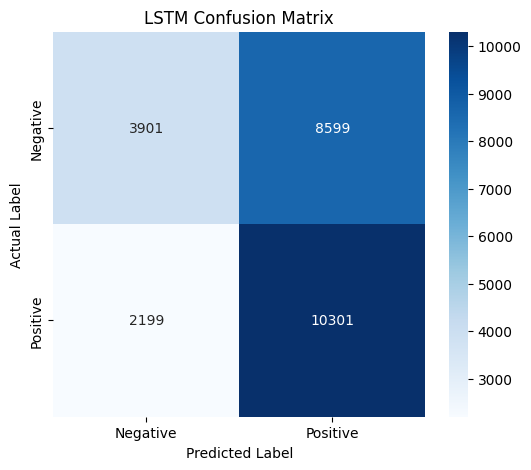

In [ ]:
# Create confusion matrix for LSTM

lstm_cm = confusion_matrix(y_test, lstm_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

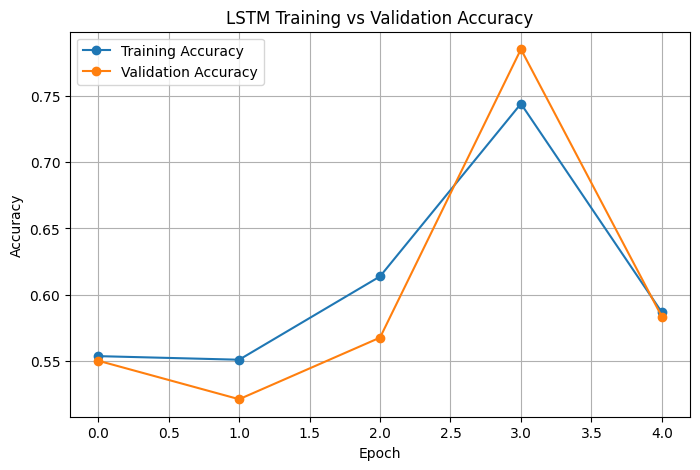

In [ ]:
# Plot LSTM training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(
  lstm_history.history['accuracy'],
  marker='o',
  label='Training Accuracy'
)

plt.plot(
  lstm_history.history['val_accuracy'],
  marker='o',
  label='Validation Accuracy'
)

plt.title('LSTM Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Why GRU?

GRU (Gated Recurrent Unit) is another improved version of the basic RNN.

Like LSTM, GRU is designed to handle long-term dependencies and reduce the vanishing-gradient problem.

However, GRU has a simpler architecture than LSTM.

### Main GRU Gates

- **Update Gate** → controls how much previous information should be retained.
- **Reset Gate** → controls how much previous information should be forgotten when processing new information.

Unlike LSTM, GRU does not use a separate memory cell. This makes it simpler and usually requires fewer parameters.

### RNN vs LSTM vs GRU

| Model | Main Idea | Complexity |
|---|---|---|
| RNN | Basic recurrent memory | Low |
| LSTM | Memory cell + 3 gates | High |
| GRU | 2 gates, no separate memory cell | Medium |

GRU aims to provide many of the benefits of LSTM while using a simpler architecture.

In [ ]:
# Build the GRU model
gru_model = keras.Sequential([
    layers.Input(shape=(max_length,)),
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    layers.GRU(rnn_units),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
gru_model.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)

# Display model architecture
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the GRU model and measure training time
start_time = time.time()
gru_history = gru_model.fit(
  X_train_padded,
  y_train,
  validation_split=0.2,
  epochs=epochs,
  batch_size=batch_size,
  verbose=1
)

gru_training_time = time.time() - start_time
print(f"\nGRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5134 - loss: 0.6920 - val_accuracy: 0.6268 - val_loss: 0.6724
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5509 - loss: 0.6875 - val_accuracy: 0.5346 - val_loss: 0.6892
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6668 - loss: 0.6202 - val_accuracy: 0.6522 - val_loss: 0.6440
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8220 - loss: 0.4015 - val_accuracy: 0.8404 - val_loss: 0.3687
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9046 - loss: 0.2461 - val_accuracy: 0.8532 - val_loss: 0.3622

GRU Training Time: 22.85 seconds


In [ ]:
# Evaluate the GRU model on the test dataset

gru_test_loss, gru_test_accuracy = gru_model.evaluate(
  X_test_padded,
  y_test,
  batch_size=batch_size,
  verbose=1
)

print(f"\nGRU Test Loss: {gru_test_loss:.4f}")
print(f"GRU Test Accuracy: {gru_test_accuracy:.4f}")
print(f"GRU Test Accuracy: {gru_test_accuracy * 100:.2f}%")

391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8422 - loss: 0.3807

GRU Test Loss: 0.3807
GRU Test Accuracy: 0.8422
GRU Test Accuracy: 84.22%


In [ ]:
# Generate predictions using the trained GRU model
gru_probabilities = gru_model.predict(
  X_test_padded,
  batch_size=batch_size,
  verbose=1
)

# Convert probabilities into class labels
gru_predictions = (gru_probabilities >= 0.5).astype(int).flatten()

# Calculate evaluation metrics
gru_accuracy = accuracy_score(y_test, gru_predictions)
gru_precision = precision_score(y_test, gru_predictions)
gru_recall = recall_score(y_test, gru_predictions)
gru_f1 = f1_score(y_test, gru_predictions)

print("GRU Evaluation Metrics")
print("-" * 30)
print(f"Accuracy : {gru_accuracy:.4f}")
print(f"Precision: {gru_precision:.4f}")
print(f"Recall   : {gru_recall:.4f}")
print(f"F1-Score : {gru_f1:.4f}")

391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
GRU Evaluation Metrics
------------------------------
Accuracy : 0.8422
Precision: 0.8113
Recall   : 0.8920
F1-Score : 0.8497


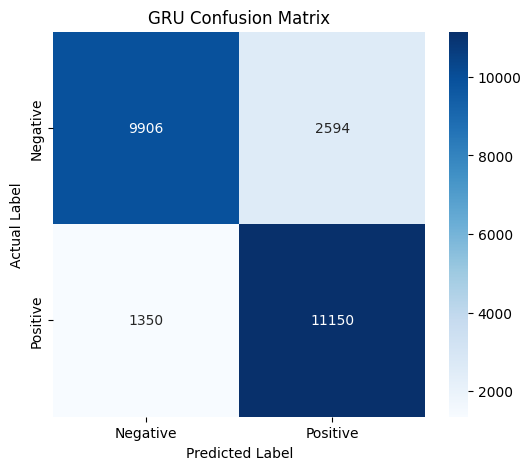

In [ ]:
# Create confusion matrix for GRU

gru_cm = confusion_matrix(y_test, gru_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    gru_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('GRU Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

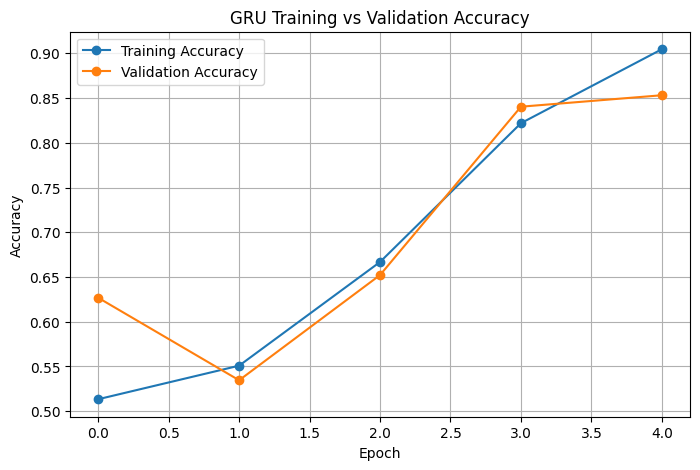

In [ ]:
# Plot GRU training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(
  gru_history.history['accuracy'],
  marker='o',
  label='Training Accuracy'
)

plt.plot(
  gru_history.history['val_accuracy'],
  marker='o',
  label='Validation Accuracy'
)

plt.title('GRU Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create a comparison table for all three models
comparison_data = {
  'Model': ['RNN', 'LSTM', 'GRU'],
  'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy],
  'Precision': [rnn_precision, lstm_precision, gru_precision],
  'Recall': [rnn_recall, lstm_recall, gru_recall],
  'F1-Score': [rnn_f1, lstm_f1, gru_f1],
  'Test Loss': [rnn_test_loss, lstm_test_loss, gru_test_loss],
  'Training Time (sec)': [
      rnn_training_time,
      lstm_training_time,
      gru_training_time
  ],
  'Parameters': [
      rnn_model.count_params(),
      lstm_model.count_params(),
      gru_model.count_params()
  ]
}
comparison_df = pd.DataFrame(comparison_data)
# Round metric values for readability
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Test Loss']] = (
    comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Test Loss']]
    .round(4)
)
comparison_df['Training Time (sec)'] = comparison_df['Training Time (sec)'].round(2)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,Training Time (sec),Parameters
0,RNN,0.5095,0.5092,0.5292,0.5190,0.8366,37.25,648321
1,LSTM,0.5681,0.5450,0.8241,0.6561,0.6674,24.76,673089
2,GRU,0.8422,0.8113,0.8920,0.8497,0.3807,22.85,665025


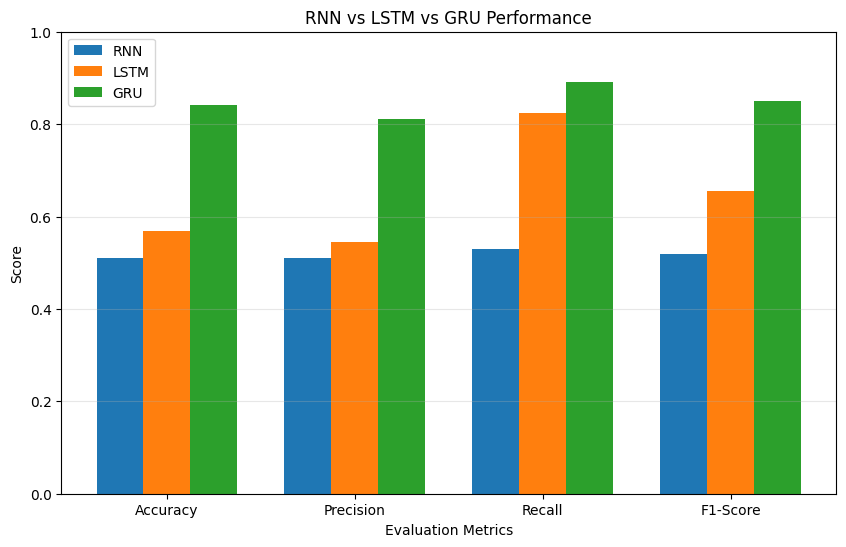

In [ ]:
# Plot Accuracy, Precision, Recall and F1-Score comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rnn_scores = [
  rnn_accuracy,
  rnn_precision,
  rnn_recall,
  rnn_f1
]
lstm_scores = [
  lstm_accuracy,
  lstm_precision,
  lstm_recall,
  lstm_f1
]
gru_scores = [
  gru_accuracy,
  gru_precision,
  gru_recall,
  gru_f1
]
x = np.arange(len(metrics))
width = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - width, rnn_scores, width, label='RNN')
plt.bar(x, lstm_scores, width, label='LSTM')
plt.bar(x + width, gru_scores, width, label='GRU')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('RNN vs LSTM vs GRU Performance')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

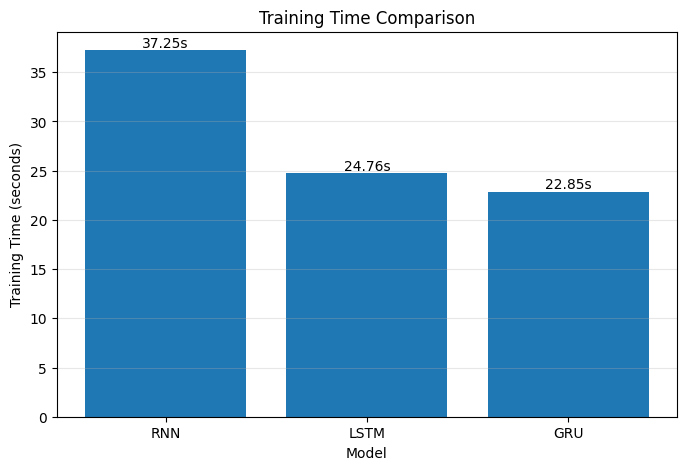

In [ ]:
# Compare training time of RNN, LSTM and GRU
models = ['RNN', 'LSTM', 'GRU']
training_times = [
  rnn_training_time,
  lstm_training_time,
  gru_training_time
]
plt.figure(figsize=(8, 5))
bars = plt.bar(models, training_times)
plt.title('Training Time Comparison')
plt.xlabel('Model')
plt.ylabel('Training Time (seconds)')
plt.grid(axis='y', alpha=0.3)
# Display values on top of bars
for bar, value in zip(bars, training_times):
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f'{value:.2f}s',
      ha='center',
      va='bottom'
  )

plt.show()

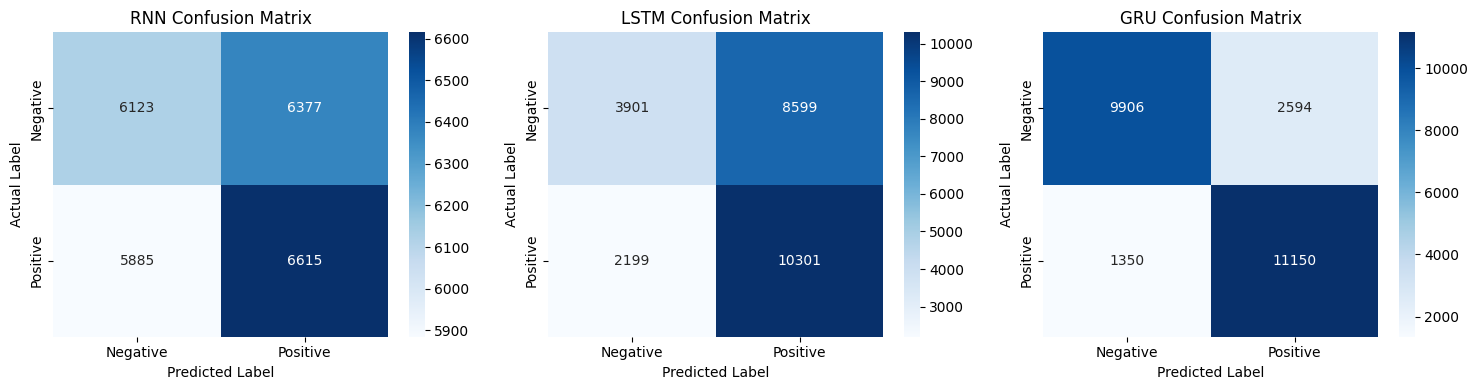

In [ ]:
# Compare confusion matrices of RNN, LSTM and GRU

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

confusion_matrices = [
    (rnn_cm, 'RNN'),
    (lstm_cm, 'LSTM'),
    (gru_cm, 'GRU')
]

for ax, (cm, model_name) in zip(axes, confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        ax=ax
    )

    ax.set_title(f'{model_name} Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

In [ ]:
# Generate detailed classification reports for all three models
print("=" * 60)
print("RNN CLASSIFICATION REPORT")
print("=" * 60)
print(
  classification_report(
    y_test,
    rnn_predictions,
    target_names=['Negative', 'Positive']
  )
)

print("=" * 60)
print("LSTM CLASSIFICATION REPORT")
print("=" * 60)
print(
  classification_report(
    y_test,
    lstm_predictions,
    target_names=['Negative', 'Positive']
  )
)

print("=" * 60)
print("GRU CLASSIFICATION REPORT")
print("=" * 60)
print(
  classification_report(
    y_test,
    gru_predictions,
    target_names=['Negative', 'Positive']
  )
)

RNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.51      0.49      0.50     12500
    Positive       0.51      0.53      0.52     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.51     25000
weighted avg       0.51      0.51      0.51     25000

LSTM CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.64      0.31      0.42     12500
    Positive       0.55      0.82      0.66     12500

    accuracy                           0.57     25000
   macro avg       0.59      0.57      0.54     25000
weighted avg       0.59      0.57      0.54     25000

GRU CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.88      0.79      0.83     12500
    Positive       0.81      0.89      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.85      0.84      0.84     2

In [ ]:
# Create a clean final results table

final_results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Accuracy (%)': [
        rnn_accuracy * 100,
        lstm_accuracy * 100,
        gru_accuracy * 100
    ],
    'Precision (%)': [
        rnn_precision * 100,
        lstm_precision * 100,
        gru_precision * 100
    ],
    'Recall (%)': [
        rnn_recall * 100,
        lstm_recall * 100,
        gru_recall * 100
    ],
    'F1-Score (%)': [
        rnn_f1 * 100,
        lstm_f1 * 100,
        gru_f1 * 100
    ],
    'Test Loss': [
        rnn_test_loss,
        lstm_test_loss,
        gru_test_loss
    ],
    'Training Time (sec)': [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ],
    'Parameters': [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

# Round numerical values
final_results = final_results.round({
    'Accuracy (%)': 2,
    'Precision (%)': 2,
    'Recall (%)': 2,
    'F1-Score (%)': 2,
    'Test Loss': 4,
    'Training Time (sec)': 2
})

display(final_results)

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),Test Loss,Training Time (sec),Parameters
0,RNN,50.95,50.92,52.92,51.90,0.8366,37.25,648321
1,LSTM,56.81,54.50,82.41,65.61,0.6674,24.76,673089
2,GRU,84.22,81.13,89.20,84.97,0.3807,22.85,665025


## Performance Analysis

Based on the experimental results, the three sequence models show significant differences in performance.

### RNN

The basic RNN achieved approximately **50.95% test accuracy** and an F1-score of **51.90%**. Its training accuracy increased during training, but validation accuracy remained close to 50%. This indicates that the basic RNN struggled to learn useful long-term dependencies from the movie reviews and showed poor generalization.

### LSTM

The LSTM achieved approximately **56.81% test accuracy** and an F1-score of **65.61%**. It performed better than the basic RNN and achieved a high positive-class recall of **82.41%**. However, its performance was still limited in this experiment, particularly for identifying negative reviews.

### GRU

The GRU achieved the best performance with approximately **84.22% test accuracy** and an **84.97% F1-score**. It also achieved **81.13% precision** and **89.20% recall**. Its training time was approximately **22.85 seconds**, which was the lowest among the three models in this particular Colab run.

### Overall Comparison

The results from this experiment are:

| Model | Accuracy | Precision | Recall | F1-Score | Training Time |
|---|---:|---:|---:|---:|---:|
| RNN | 50.95% | 50.92% | 52.92% | 51.90% | 37.25 s |
| LSTM | 56.81% | 54.50% | 82.41% | 65.61% | 24.76 s |
| **GRU** | **84.22%** | **81.13%** | **89.20%** | **84.97%** | **22.85 s** |

In this experiment, **GRU performed the best** among the three models. It provided the highest classification performance while also having fewer parameters than LSTM.

The training-time comparison should be interpreted as an observation from this particular Colab run because execution time can vary depending on the available hardware and system load.

## Conclusion

In this assignment, RNN, LSTM, and GRU models were implemented and compared for binary sentiment classification using the IMDB Movie Reviews dataset.

The basic RNN achieved **50.95% accuracy**, while LSTM achieved **56.81% accuracy**. The GRU achieved the highest accuracy of **84.22%** and an F1-score of **84.97%** in this experiment.

The results demonstrate that gated recurrent architectures can provide better sequence learning capabilities than a basic RNN. Among the tested models, GRU provided the best overall classification performance and also had the lowest training time in this particular experiment.

Therefore, for this IMDB sequence classification experiment, **GRU was the best-performing model** based on Accuracy, Precision, Recall, F1-score, and observed training time.